## Tech Challenge 2

## Classificação da Qualidade de Vinhos

### Objetivo

Este projeto tem como objetivo desenvolver dois modelos de Machine Learning capazes
de classificar vinhos como de alta qualidade (nota >= 7) ou de baixa/média qualidade (nota < 7), utilizando
suas características físico-químicas.

A variável original `quality` será transformada em uma variável binária chamada `target`:

- 0: vinho de baixa ou média qualidade, com nota inferior a 7;
- 1: vinho de alta qualidade, com nota igual ou superior a 7.

## 1. Importação das bibliotecas

Nesta etapa são importadas as bibliotecas utilizadas para manipulação dos dados,
visualização gráfica, pré-processamento e construção dos modelos de classificação.

In [29]:
# Biblioteca para manipulação e análise de dados
import pandas as pd

# Bibliotecas para criação de gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# Bibliotecas para criação e teste de modelos de classificação
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,balanced_accuracy_score, recall_score,f1_score,precision_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


## 2. Carregamento dos dados

O dataset contém características físico-químicas de diferentes amostras de vinho,
além da nota de qualidade atribuída.

In [ ]:
# Importanto o Daset
df_vinhos = pd.read_csv(r"WineQT.csv")
# Exibe os cinco primeiros registros
df_vinhos.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


## 3. Análise inicial da base

Antes da análise exploratória, verificaremos a quantidade de registros, tipos das variáveis, valores ausentes e possíveis duplicidades.

In [3]:
# Exibe a quantidade de linhas e colunas do dataset
print(f"Quantidade de linhas: {df_vinhos.shape[0]}")
print(f"Quantidade de colunas: {df_vinhos.shape[1]}")

Quantidade de linhas: 1143
Quantidade de colunas: 13


In [4]:
# Exibe os tipos das variáveis e a quantidade de valores não nulos
df_vinhos.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [5]:
# Calcula a quantidade de valores nulos que existem no dataframe
df_vinhos.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

### Resultado

Não foram encontrados valores nulos no dataset. Portanto, não será necessário
realizar técnicas de preenchimento ou exclusão de registros por ausência de dados.

## 4. Estatísticas descritivas

As estatísticas descritivas permitem observar a distribuição inicial das variáveis, incluindo média, desvio-padrão, valores mínimos, máximos e quartis.

In [6]:
print(df_vinhos.describe().T)

                       count        mean         std      min        25%  \
fixed acidity         1143.0    8.311111    1.747595  4.60000    7.10000   
volatile acidity      1143.0    0.531339    0.179633  0.12000    0.39250   
citric acid           1143.0    0.268364    0.196686  0.00000    0.09000   
residual sugar        1143.0    2.532152    1.355917  0.90000    1.90000   
chlorides             1143.0    0.086933    0.047267  0.01200    0.07000   
free sulfur dioxide   1143.0   15.615486   10.250486  1.00000    7.00000   
total sulfur dioxide  1143.0   45.914698   32.782130  6.00000   21.00000   
density               1143.0    0.996730    0.001925  0.99007    0.99557   
pH                    1143.0    3.311015    0.156664  2.74000    3.20500   
sulphates             1143.0    0.657708    0.170399  0.33000    0.55000   
alcohol               1143.0   10.442111    1.082196  8.40000    9.50000   
quality               1143.0    5.657043    0.805824  3.00000    5.00000   
Id          

## 5. Criação da variável-alvo

A variável `quality` possui a nota original atribuída ao vinho. Para transformar
o problema em uma classificação binária, será criada a variável `target`.

Vinhos com nota igual ou superior a 7 serão classificados como alta qualidade.
Os demais serão classificados como baixa ou média qualidade.

In [7]:
# Criação da variavel alvo
# 0 representa vinhos de baixa ou média qualidade
# 1 representa vinhos de alta qualidade
df_vinhos["target"] = (df_vinhos["quality"]>= 7).astype(int)

In [8]:
# Amostra da relação entre a nota original e a classificação criada
df_vinhos[["quality", "target"]].head(10)

,quality,target
0,5,0
1,5,0
2,5,0
3,6,0
4,5,0
5,5,0
6,5,0
7,7,1
8,7,1
9,5,0


## 6. Análise do balanceamento das classes

Nesta etapa será analisada a proporção de vinhos de alta qualidade e de
baixa/média qualidade. Essa análise é importante porque classes desbalanceadas
podem influenciar o treinamento e a avaliação dos modelos.

,Quantidade,Percentual (%)
Baixa/Média Qualidade,984,86.09
Alta Qualidade,159,13.91


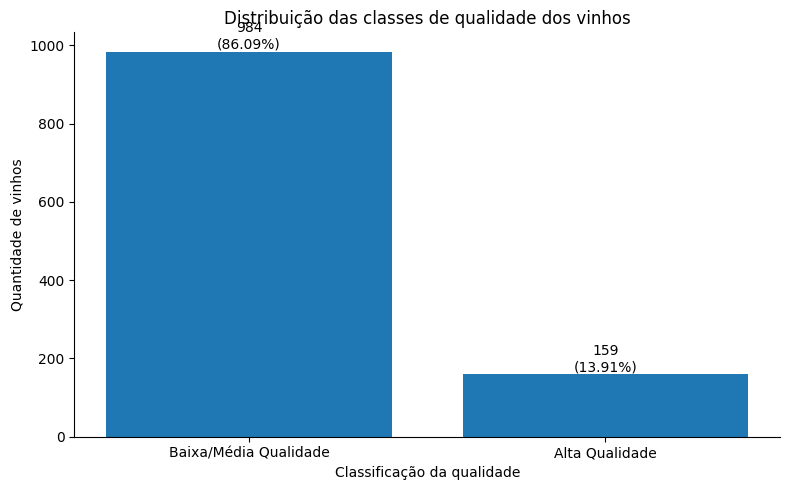

In [9]:
# Calcula a quantidade de registros de cada classe
quantidade_classes = df_vinhos["target"].value_counts()

# Calcula o percentual de cada classe
percentual_classes = (
    df_vinhos["target"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

# Organiza os resultados em uma tabela
distribuicao_classes = pd.DataFrame({
    "Quantidade": quantidade_classes,
    "Percentual (%)": percentual_classes
})

# Substitui os valores 0 e 1 por nomes mais descritivos
distribuicao_classes.index = [
    "Baixa/Média Qualidade",
    "Alta Qualidade"
]

# Exibe a tabela
display(distribuicao_classes)

# Cria o gráfico de barras
fig, ax = plt.subplots(figsize=(8, 5))

barras = ax.bar(
    distribuicao_classes.index,
    distribuicao_classes["Quantidade"]
)

# Adiciona quantidade e percentual acima de cada barra
for barra, quantidade, percentual in zip(
    barras,
    distribuicao_classes["Quantidade"],
    distribuicao_classes["Percentual (%)"]
):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height(),
        f"{quantidade}\n({percentual:.2f}%)",
        ha="center",
        va="bottom"
    )

# Personaliza o gráfico
ax.set_title("Distribuição das classes de qualidade dos vinhos")
ax.set_xlabel("Classificação da qualidade")
ax.set_ylabel("Quantidade de vinhos")

# Remove as bordas superior e direita
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Interpretação

Os vinhos de Baixa/Média Qualidade representam a maior parte dos registros da nossa base, enquanto os vinhos de Alta Qualidade possuem
uma participação menor. Isso demonstra que o dataset apresenta desbalanceamento entre as classes.

Por esse motivo, a avaliação dos modelos não deverá considerar apenas a acurácia.
Também serão utilizadas métricas como precisão, recall e F1-score.

## 7. Distribuição das variáveis numéricas

Os histogramas serão utilizados para avaliar a distribuição das variáveis,
identificar assimetrias e observar possíveis valores extremos.

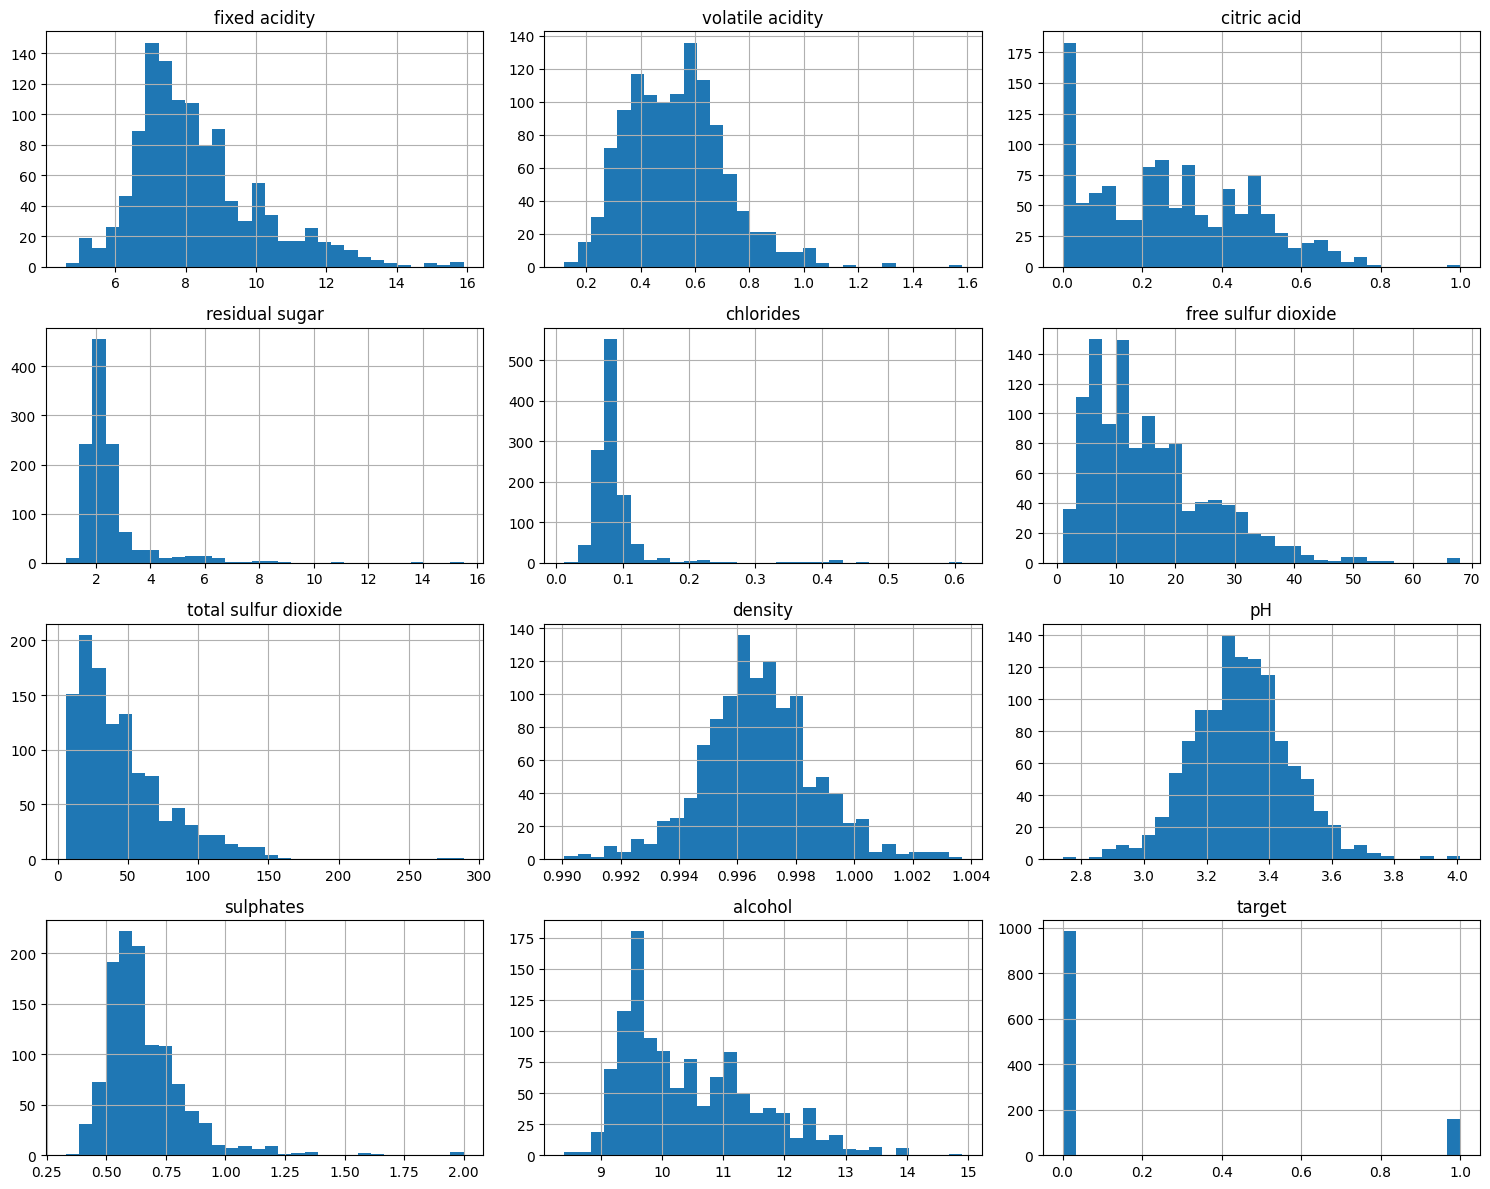

In [10]:
# Remove as variáveis de qualidade para analisar somente as características físico-químicas utilizadas como variáveis explicativas
variaveis_explicativas = df_vinhos.drop(
    columns=['quality','targe','Id'],
    errors='ignore'
)

# Cria histogramas para todas as variáveis explicativas
variaveis_explicativas.hist(figsize=(15,12),bins=30)

# Ajusta o espaçamento entre os gráficos
plt.tight_layout()
plt.show()


### Interpretação

* As variáveis `density` e `pH` apresentam distribuições aproximadamente simétricas, com maior concentração de valores ao redor da média e poucos registros nas extremidades.

* A variável `fixed acidity` apresenta maior concentração entre aproximadamente **7 e 9**, com uma cauda mais longa à direita. Isso indica a presença de algumas amostras com níveis de acidez fixa superiores ao padrão predominante.

* A variável `volatile acidity` possui distribuição relativamente concentrada entre **0,3 e 0,8**, mas apresenta alguns valores elevados e isolados, que deverão ser investigados como possíveis *outliers*.

* A variável `citric acid` apresenta elevada concentração de registros próximos de zero e distribuição assimétrica à direita. Esse comportamento indica que uma parcela relevante das amostras possui baixa concentração de ácido cítrico.

* As variáveis `residual sugar` e `chlorides` apresentam forte assimetria à direita. A maior parte das amostras está concentrada em valores baixos, enquanto poucos registros apresentam valores consideravelmente mais elevados.

* As variáveis `free sulfur dioxide` e `total sulfur dioxide` também apresentam distribuições assimétricas à direita, com maior concentração nas faixas inferiores e presença de valores extremos. Esses registros deverão ser analisados antes de qualquer decisão de tratamento ou exclusão.

* A variável `sulphates` apresenta maior concentração entre aproximadamente **0,5 e 0,8**, além de uma cauda à direita e alguns valores elevados em relação ao conjunto predominante.

* A variável `alcohol` apresenta maior concentração entre aproximadamente **9% e 12%**, com menor frequência de vinhos com teor alcoólico mais elevado. Sua distribuição não aparenta ser perfeitamente normal e apresenta uma cauda à direita.

* Os histogramas indicam possíveis valores extremos em diversas variáveis. Entretanto, esses registros não devem ser removidos automaticamente, pois podem representar características físico-químicas legítimas de determinadas amostras de vinho. A análise será complementada por meio de *boxplots* e critérios estatísticos, como o intervalo interquartil.

* As variáveis possuem escalas significativamente diferentes. Por exemplo, `density` apresenta valores próximos de **1**, enquanto `total sulfur dioxide` pode alcançar valores próximos de **300**. Por esse motivo, a padronização será importante para modelos sensíveis à escala, como Regressão Logística, KNN e SVM.

* A coluna `Id` apresenta distribuição aproximadamente uniforme por representar apenas a identificação dos registros. Como não contém uma característica físico-química do vinho, deverá ser removida das variáveis utilizadas no treinamento dos modelos.


## 8.Análise de possíveis outliers

Após a análise das distribuições, serão utilizados boxplots para identificar
valores que se encontram distantes da maior parte dos registros.

Nesta etapa, os valores extremos serão apenas investigados. Eles não serão
removidos automaticamente, pois podem representar características
físico-químicas legítimas de determinadas amostras de vinho.

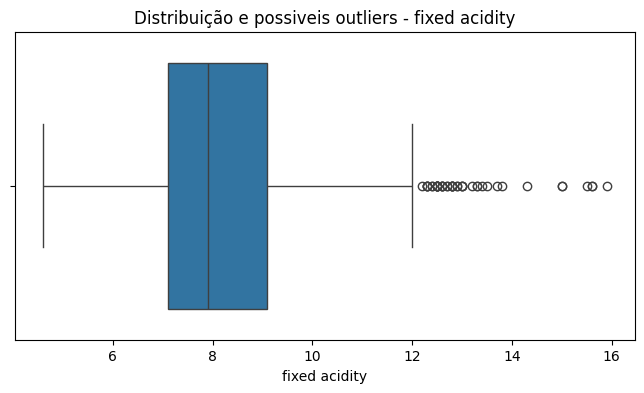

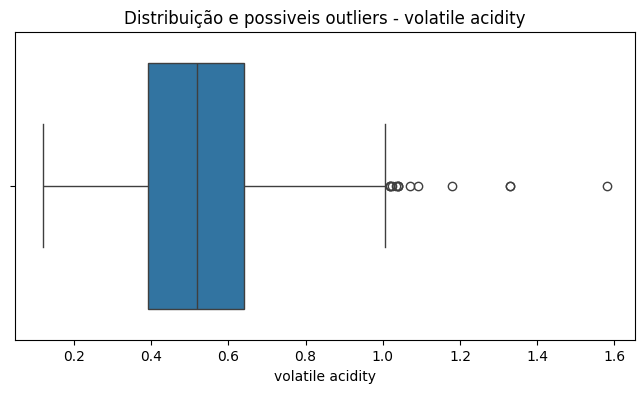

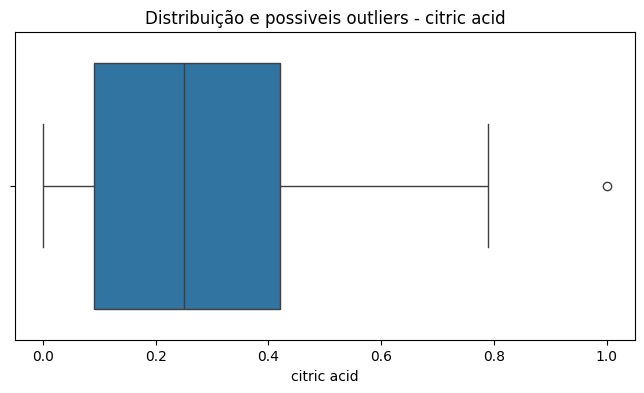

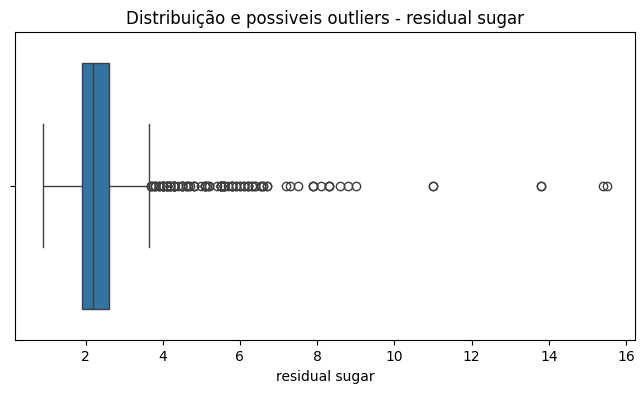

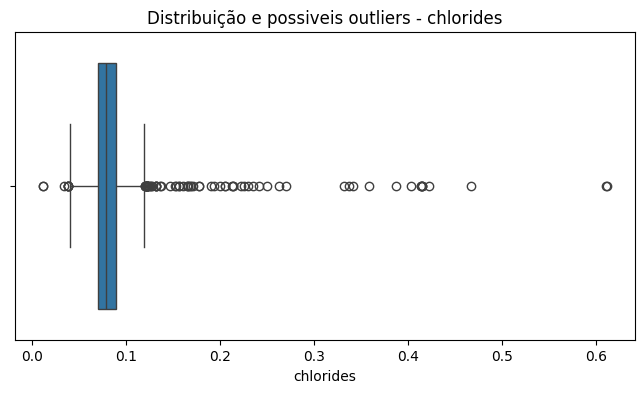

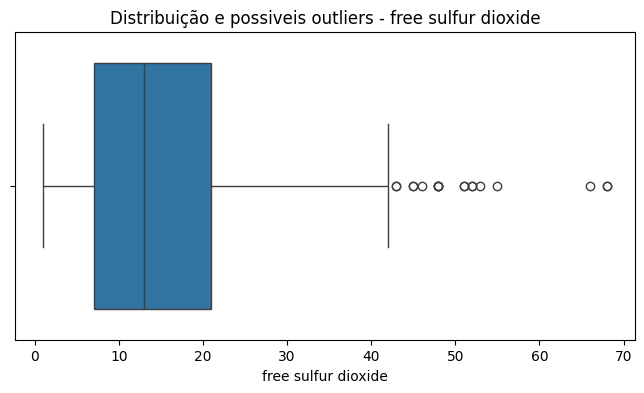

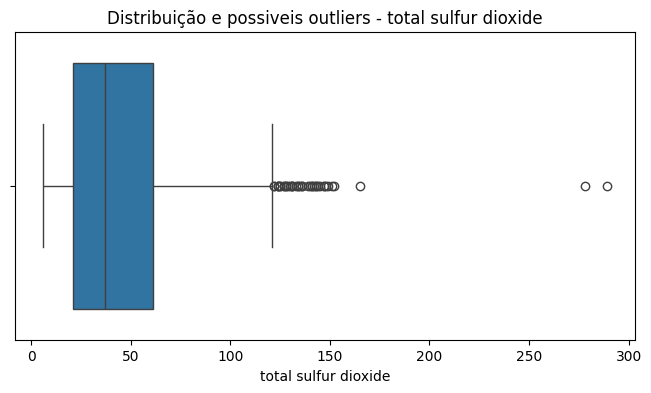

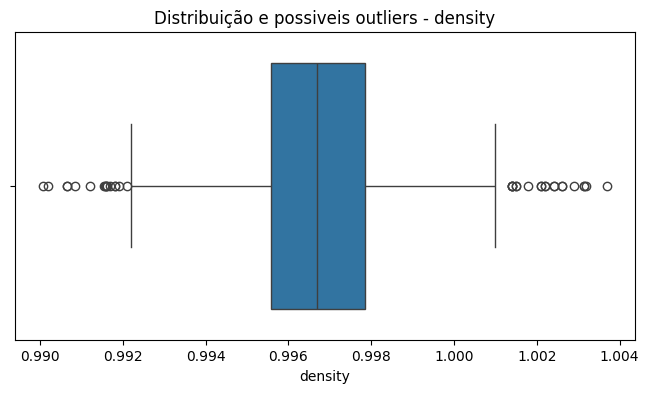

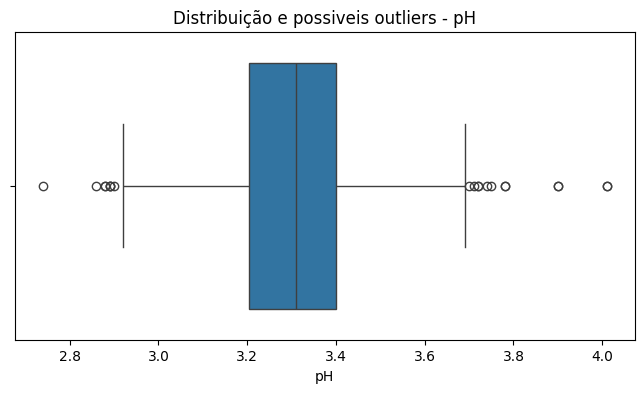

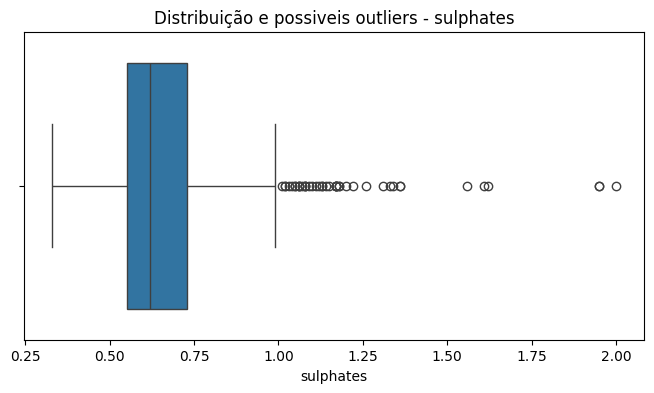

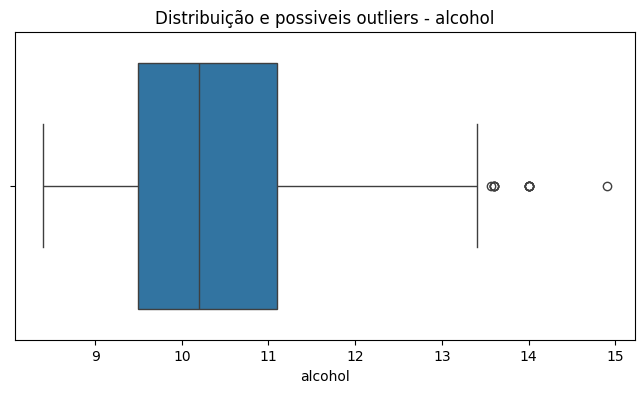

In [11]:
df_vinhos_sem_id = df_vinhos.drop(columns="Id")

# Seleciona apenas as variáveis físico-químicas
colunas_numericas = df_vinhos_sem_id.drop(
    columns=["quality","target"],
    errors="ignore"
).columns

#Criação do bloxpot
for coluna in colunas_numericas:
    plt.figure(figsize=(8,4))

    sns.boxplot(x=df_vinhos_sem_id[coluna])

    plt.title(f"Distribuição e possiveis outliers - {coluna}")
    plt.xlabel(coluna)

    plt.tight_layout
    plt.show()

### Interpretação

A análise dos boxplots identificou possíveis valores extremos em praticamente todas as variáveis físico-químicas do conjunto de dados. Entretanto, a quantidade e a intensidade desses valores variam entre as características analisadas.

As variáveis `residual sugar`, `chlorides`, `fixed acidity`, `total sulfur dioxide` e `sulphates` apresentam maior quantidade de observações acima dos limites superiores dos boxplots. Esse resultado está relacionado, em parte, às distribuições assimétricas à direita observadas anteriormente nos histogramas.

As variáveis `density` e `pH` apresentam possíveis outliers nos dois extremos da distribuição, enquanto `citric acid` e `alcohol` possuem apenas alguns valores isolados.

Apesar de serem classificados estatisticamente como outliers pelo critério visual dos boxplots, esses registros não serão removidos automaticamente. Como as variáveis representam características físico-químicas dos vinhos, valores extremos podem corresponder a amostras legítimas e não necessariamente a erros de preenchimento ou medição.

Dessa forma, a próxima etapa será quantificar os outliers por variável utilizando o método do intervalo interquartil. A decisão sobre eventual tratamento será realizada posteriormente, considerando a plausibilidade dos valores e o impacto deles no desempenho dos modelos.

Transformando a analise visual e tabelas para melhorar a analise dos Outliers

In [12]:
# Lista que armazenará os resultados de cada variável
resultado_outliers = []

# Percorre todas as variáveis numéricas
for coluna in colunas_numericas:
    #Calculo do 1 e 3 quartil
    q1 = df_vinhos_sem_id[coluna].quantile(0.25)
    q3 = df_vinhos_sem_id[coluna].quantile(0.75)

    #Calculo do interquartil
    iqr = q3 - q1
    
    #Definição de limite superior e inferior
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    #Identificação dos registros outliers
    outliers = (
        (df_vinhos_sem_id[coluna] < limite_inferior) |
        (df_vinhos_sem_id[coluna] > limite_superior)
    )

    #Calculo da quantidade e percentual de outliers
    qtd_outliers = outliers.sum()
    pct_outliers = (qtd_outliers/len(df_vinhos_sem_id))*100

    #Armazenando os resultados
    resultado_outliers.append({
        "Variavel": coluna,
        "Limite Inferior": round(limite_inferior,4),
        "Limete Superior": round(limite_superior,4),
        "Quantidade Outliers":qtd_outliers,
        "Percentual de Outliers": round(pct_outliers,2)
    })

#Transformando em df
tabela_outliers = pd.DataFrame(resultado_outliers)

#Ordenando do maior para o menor
tabela_outliers = tabela_outliers.sort_values(by="Quantidade Outliers",ascending=False)

print(tabela_outliers)

                Variavel  Limite Inferior  Limete Superior  \
3         residual sugar           0.8500           3.6500   
4              chlorides           0.0400           0.1200   
0          fixed acidity           4.1000          12.1000   
9              sulphates           0.2800           1.0000   
6   total sulfur dioxide         -39.0000         121.0000   
7                density           0.9922           1.0013   
8                     pH           2.9125           3.6925   
5    free sulfur dioxide         -14.0000          42.0000   
1       volatile acidity           0.0213           1.0112   
10               alcohol           7.1000          13.5000   
2            citric acid          -0.4050           0.9150   

    Quantidade Outliers  Percentual de Outliers  
3                   110                    9.62  
4                    77                    6.74  
0                    44                    3.85  
9                    43                    3.76  
6    

### Conclusão da Analise de Outliers

A análise pelo método de interquartil identificou possíveis valores extremos em todas as variáveis do dataset, porém em diferentes proporções.

A variável `residual sugar` apresentou a maior concentração de outliers, com 110 registros, equivalentes a 9,62% da base de dados. Seguida da variavel `chlorides` que apresentou 77 registros, correspondentes a 6,74%.

As variáveis `fixed acidity`, `sulphates`, `total sulfur dioxide` e `density` apresentaram percentuais entre aproximadamente 3% e 4%. Nas demais variáveis, os possíveis outliers representaram menos de 2% dos registros, com exceção de `citric acid`, que apresentou apenas um caso, equivalente a 0,09% dos dados.

A maior quantidade de outliers em `residual sugar` e `chlorides` está relacionada às distribuições assimétricas observadas anteriormente. Dessa forma, parte dos registros identificados pelo método pode representar características legítimas dos vinhos, e não necessariamente erros de preenchimento ou medição.

Por esse motivo, os possíveis outliers serão inicialmente mantidos no conjunto de dados. A remoção poderia causar perda de informações relevantes e alterar a distribuição original das variáveis. O impacto desses valores será avaliado posteriormente durante o treinamento e a comparação dos modelos.

## 9.Análise de correlação entre as variaveis

Após o tratamento dos outliers, utilizaremos a matriz de correlação para avaliar a relação entre as variáveis e a variável-alvo, bem como identificar possíveis correlações entre elas. Essa análise permitirá compreender quais atributos possuem maior relação o com a qualidade do vinho.

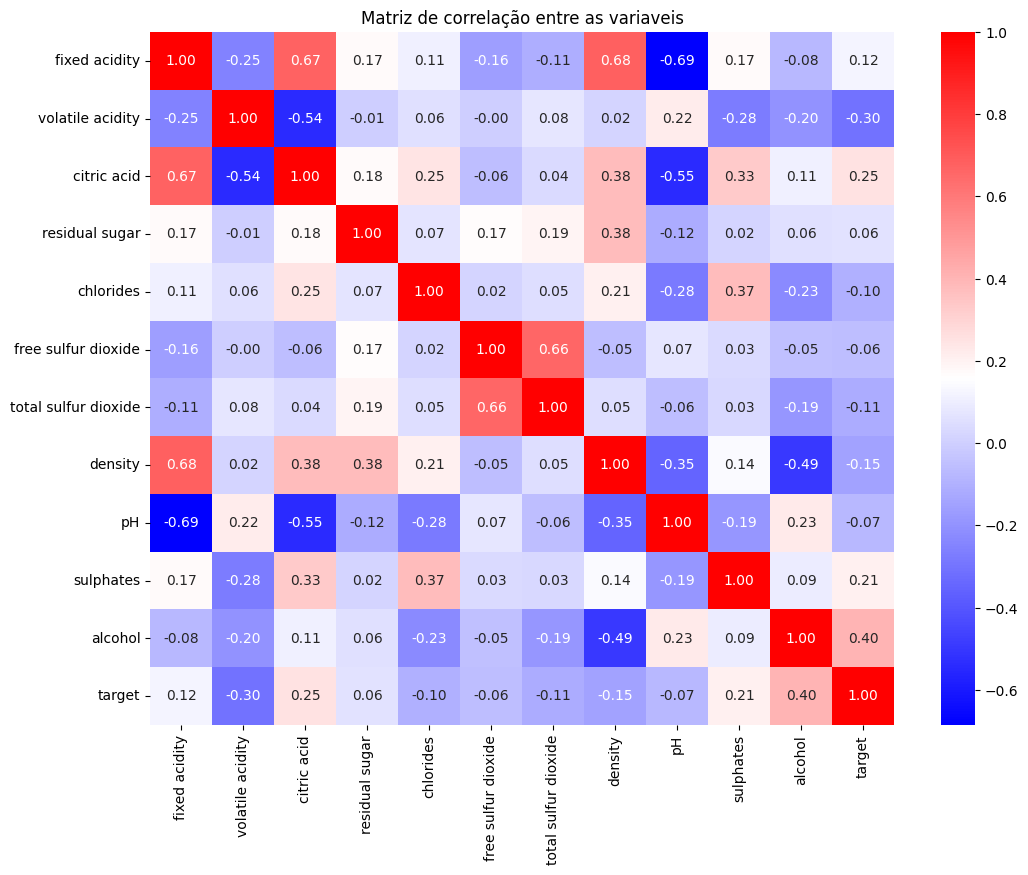

In [13]:
#Utilizando o Df anterior e removendo a variavel quality.
df_correlacao = df_vinhos_sem_id.drop(columns=["quality"], errors="ignore")

#Calculando a correlação entre as variaveis
matriz_correlacao = df_correlacao.corr(numeric_only=True)

#Criando Mapa de Calor
plt.figure(figsize=(12,9))

sns.heatmap(
    matriz_correlacao,
    cmap="bwr",
    annot=True,
    fmt=".2f",
)

plt.title("Matriz de correlação entre as variaveis")
plt.tight_layout
plt.show()

In [14]:
# Selecionando e ordenando as correlações com a variável-alvo
correlacao_target = (
    matriz_correlacao["target"]
    .drop("target")
    .sort_values(ascending=False)
)

correlacao_target

alcohol                 0.403676
citric acid             0.251146
sulphates               0.208020
fixed acidity           0.123212
residual sugar          0.064145
free sulfur dioxide    -0.055977
pH                     -0.073318
chlorides              -0.103985
total sulfur dioxide   -0.113373
density                -0.148670
volatile acidity       -0.304523
Name: target, dtype: float64

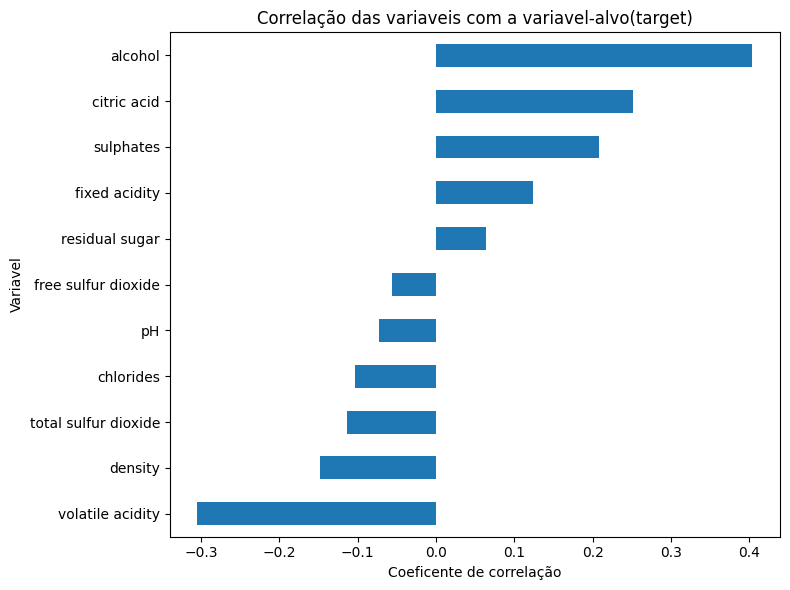

In [15]:
# Criando gráfico com as correlações em relação ao target
correlacao_target.sort_values().plot(kind="barh",figsize=(8,6))
plt.title("Correlação das variaveis com a variavel-alvo(target)")
plt.xlabel("Coeficente de correlação")
plt.ylabel("Variavel")
plt.tight_layout()
plt.show()

### Conclusão da análise de correlação

A análise de correlação indica que o teor alcoólico (`alcohol`) é a variável com maior relação linear com a variavel-alvo, com uma variação positiva de aproximadamente **0,40**. Isso sugere que vinhos com maior teor alcoólico tendem a ser classificados como de alta qualidade.

As variáveis `citric acid` e `sulphates` também apresentaram correlações positivas com o variavel-alvo, com coeficientes de **0,25** e **0,21**, respectivamente. Essas relações são moderadas, mas podem indicar que essas características podem estar associadas a vinhos classificados como de alta qualidade.

A variável `volatile acidity` apresentou a correlação negativa mais relevante com a variável-alvo, com coeficiente de **-0,30**. Esse resultado indica que vinhos com acidez volátil maior tendem a estar associados a vinhos de baixa ou média qualidade.

As variáveis `density`, `total sulfur dioxide` e `chlorides` também apresentaram correlações negativas com o `target`, embora com intensidades menores. Já `residual sugar`, `free sulfur dioxide` e `pH` demonstraram relações lineares fracas com a classificação de qualidade.

Também foram identificadas correlações relevantes entre algumas variáveis explicativas. Entre as principais relações observadas estão:

* `fixed acidity` e `pH`: correlação de aproximadamente **-0,69**;
* `fixed acidity` e `density`: correlação de aproximadamente **0,68**;
* `fixed acidity` e `citric acid`: correlação de aproximadamente **0,67**;
* `free sulfur dioxide` e `total sulfur dioxide`: correlação de aproximadamente **0,66**;
* `citric acid` e `pH`: correlação de aproximadamente **-0,55**;
* `volatile acidity` e `citric acid`: correlação de aproximadamente **-0,54**;
* `alcohol` e `density`: correlação de aproximadamente **-0,49**.

Essas relações indicam que algumas características físico-químicas variam de forma conjunta. Entretanto, não foram observadas correlações extremamente elevadas, próximas de 0,90 ou 1,00, que justificassem a remoção imediata de variáveis por redundância.

É importante destacar que correlação não representa causalidade. Uma correlação linear baixa com o `target` não significa que a variável seja irrelevante para os modelos, pois podem existir relações não lineares ou interações com outras características.

Dessa forma, todas as variáveis físico-químicas serão inicialmente mantidas para o treinamento dos modelos.


# 10.Pré-processamento
Com a etapa de Análise Exploratória de Dados (EDA) concluída, iniciaremos o processo de pré processamento dos dados para o modelo de Machine Learning. Nesta fase, os dados serão preparados, divididos entre conjuntos de treino e teste e, posteriormente, utilizados para o treinamento, avaliação e comparação dos algoritmos selecionados.

In [16]:
# Seleciona as características físico-químicas utilizadas pelos modelos
# As colunas Id, quality e target não devem ser utilizadas como variáveis explicativas
x = df_vinhos.drop(columns=["Id", "quality", "target"],errors="ignore")

# Define a variável que será prevista pelos modelos
y = df_vinhos["target"]

In [17]:
# Verifica as dimensões das variáveis explicativas
print("Dimensões de x:", x.shape)

# Verifica as dimensões da variável-alvo
print("Dimensões de y:", y.shape)

# Exibe as variáveis que serão utilizadas pelos modelos
print("\nVariáveis explicativas:")
print(x.columns.tolist())

Dimensões de x: (1143, 11)
Dimensões de y: (1143,)

Variáveis explicativas:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


In [18]:
# Dividindo os dados em treino e teste
# O parâmetro stratify preserva a proporção original das classes
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.20,random_state=101,stratify=y)

#Validação da Divisão
print("Conjunto de treino:")
print("X_train:", x_train.shape)
print("y_train:", y_train.shape)

print("\nConjunto de teste:")
print("X_test:", x_test.shape)
print("y_test:", y_test.shape)

Conjunto de treino:
X_train: (914, 11)
y_train: (914,)

Conjunto de teste:
X_test: (229, 11)
y_test: (229,)


In [19]:
# Verificando se a proporção das classes foi preservada
print("Distribuição no conjunto de treino:")
print(
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nDistribuição no conjunto de teste:")
print(
    y_test.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Distribuição no conjunto de treino:
target
0    86.11
1    13.89
Name: proportion, dtype: float64

Distribuição no conjunto de teste:
target
0    86.03
1    13.97
Name: proportion, dtype: float64


## 11.Balanceamento da base de treinamento

Como a proporção das classes foi preservada durante a divisão dos dados e, a análise da variável-alvo demonstrou que o conjunto de dados apresenta desbalanceamento entre as classes, com maior proporção de vinhos classificados como de baixa ou média qualidade, aplicaremos o oversampling exclusivamente ao conjunto de treino, evitando o vazamento de dados (data leakage) e garantindo uma avaliação mais confiável do modelo.

Para reduzir o impacto desse desbalanceamento durante o treinamento dos modelos, foi aplicada a técnica de oversampling aleatório na classe minoritária.

O procedimento foi realizado somente após a divisão entre treino e teste e exclusivamente sobre o conjunto de treinamento. Dessa forma, o conjunto de teste permaneceu com a distribuição original dos dados, permitindo uma avaliação mais realista do desempenho dos modelos, e evitando um possivel vazamento de dados (data leak)

O oversampling foi realizado por meio da função `resample`, com reposição de registros da classe minoritária até que ela atingisse a mesma quantidade de
registros da classe majoritária.


In [20]:
# Reúne as variáveis explicativas e o target do conjunto de treino
df_treino = pd.concat(
    [
        x_train.reset_index(drop=True),
        y_train.reset_index(drop=True)
    ],
    axis=1
)

df_treino.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,target
0,8.9,0.500,0.21,2.2,0.088,21.0,39.0,0.99692,3.33,0.83,11.1,0
1,8.0,0.380,0.44,1.9,0.098,6.0,15.0,0.99560,3.30,0.64,11.4,0
2,10.0,0.380,0.38,1.6,0.169,27.0,90.0,0.99914,3.15,0.65,8.5,0
3,8.4,1.035,0.15,6.0,0.073,11.0,54.0,0.99900,3.37,0.49,9.9,0
4,8.3,0.615,0.22,2.6,0.087,6.0,19.0,0.99820,3.26,0.61,9.3,0


In [21]:
# Classe 0: vinhos de baixa/média qualidade
df_majority = df_treino[df_treino["target"] == 0]

# Classe 1: vinhos de alta qualidade
df_minority = df_treino[df_treino["target"] == 1]

# Aumenta a classe minoritária por meio da duplicação aleatória de registros até atingir o tamanho da classe majoritária
df_minority_upsampled = resample(df_minority,replace=True,n_samples=len(df_majority),random_state=101)

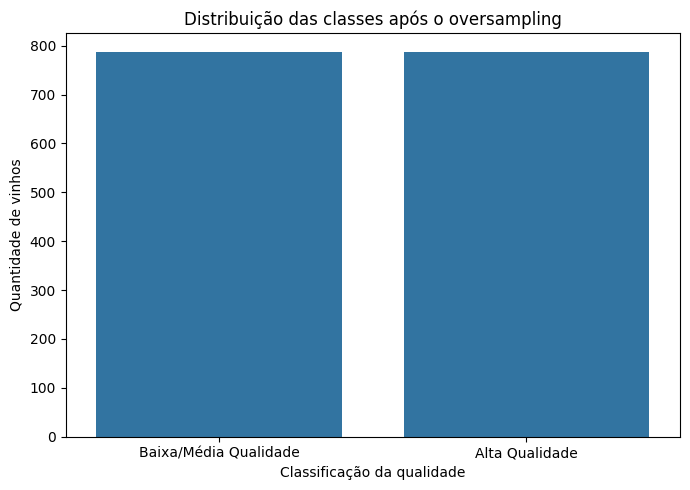

In [22]:
# Reúne a classe majoritária com a classe minoritária balanceada
df_treino_balanceado = pd.concat([df_majority,df_minority_upsampled])

# Embaralha os registros da base balanceada
df_treino_balanceado = (df_treino_balanceado.sample(frac=1, random_state=101).reset_index(drop=True))

# Verifica a distribuição das classes após o oversampling
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_treino_balanceado,
    x="target"
)

plt.title("Distribuição das classes após o oversampling")
plt.xlabel("Classificação da qualidade")
plt.ylabel("Quantidade de vinhos")
plt.xticks(
    ticks=[0, 1],
    labels=["Baixa/Média Qualidade", "Alta Qualidade"]
)

plt.tight_layout()
plt.show()

In [23]:
# Remove o target para formar as variáveis explicativas balanceadas
x_treino_balanceado = df_treino_balanceado.drop(columns=["target"])

# Define o target balanceado
y_treino_balanceado = df_treino_balanceado["target"]

## 12. Desenvolvimento dos Modelos

Após a conclusão da análise exploratória e do pré-processamento dos dados, serão desenvolvidos modelos de Machine Learning para classificar os vinhos
como de baixa/média qualidade ou de alta qualidade. Foram selecionados dois algoritmos de classificação:

- **Árvore de Decisão:** modelo baseado na criação de regras de decisão a partir das características físico-químicas dos vinhos;
- **Support Vector Machine (SVM):** modelo que busca encontrar uma fronteira capaz de separar as classes analisadas.

Os modelos serão treinados utilizando o conjunto de treinamento balanceado por oversampling. O conjunto de teste permaneceu com sua distribuição original,
permitindo avaliar o desempenho dos modelos em um cenário mais próximo da distribuição real dos dados.

In [24]:
# Criando a Arvore de Decisão (usaremos limitações para evitar overfitting)

modelo_arvore = DecisionTreeClassifier(max_depth=5,min_samples_split=10,min_samples_leaf=5,random_state=101)

# Treinando o Modelo
modelo_arvore.fit(x_treino_balanceado,y_treino_balanceado)

# Realizando as previsões
y_pred_arvore = modelo_arvore.predict(x_test)

### 12.1 Árvore de Decisão

A Árvore de Decisão foi utilizada por sua capacidade de criar regras de classificação a partir das características dos vinhos e representar relações
não lineares entre as variáveis.

Durante os testes iniciais dos modelos de classificação, foi identificado que um modelo de árvore sem restrições apresentaria acurácia de 100% no conjunto de treinamento, indicando possível overfitting. Por esse motivo, foram aplicadas limitações de profundidade e de quantidade mínima de registros nos nós e folhas.

In [25]:
# Cria o Modelo SVM

scaler = StandardScaler()

# Aprende a média e desvio padrão da base de treino
scaler.fit(x_train)

# Aplica a padronização a base de treino balanceada
x_treino_balanceado_padronizado = scaler.transform(x_treino_balanceado)

# Aplica no teste a transformação aprendida com o treino
x_test_padronizado = scaler.transform(x_test)

In [26]:
# Cria o Modelo SVM
modelo_svm = SVC(kernel="rbf",C=1.0,gamma="scale",probability=True,random_state=101)

# Treina o modelo
modelo_svm.fit(x_treino_balanceado_padronizado,y_treino_balanceado)

# Realiza a previsão dos modelos
y_pred_svm = modelo_svm.predict(x_test_padronizado)

# Calcula as probabilidades previstas para a classe de alta qualidade
y_prob_svm = modelo_svm.predict_proba(x_test_padronizado)[:,1]

### 12.2 Support Vector Machine

O Support Vector Machine foi utilizado como segundo modelo de classificação. O algoritmo busca encontrar uma fronteira capaz de separar os vinhos de
baixa/média qualidade dos vinhos de alta qualidade.

Foi utilizado o kernel RBF, que permite ao modelo representar relações não lineares entre as características físico-químicas.

Como o SVM é sensível às diferentes escalas das variáveis, foi realizada a padronização dos dados antes do treinamento. Os parâmetros da padronização
foram calculados exclusivamente a partir do conjunto de treinamento, evitando o vazamento de informações do conjunto de teste.

In [27]:
print("Previsões da Árvore:", len(y_pred_arvore))
print("Previsões do SVM:", len(y_pred_svm))
print("Registros do teste:", len(y_test))

Previsões da Árvore: 229
Previsões do SVM: 229
Registros do teste: 229


## 13. Avaliação dos Modelos

Após o treinamento, os modelos serão avaliados utilizando o conjunto de teste, que permaneceu com a distribuição original das classes.

Como a variável-alvo apresenta desbalanceamento, a avaliação não será baseada apenas na acurácia. Também serão consideradas as métricas de precisão, recall, F1-score e acurácia balanceada, com atenção especial à classe de alta qualidade.

In [ ]:
# Organizando as previsões em um dicionario
previsoes = {
    "Arvore de decisão": y_pred_arvore,
    "SVM":y_pred_svm
}

resultados = []

for nome_modelo, previsao in previsoes.items():

    resultados.append({
        "Modelo":nome_modelo,
        "Acurácia":accuracy_score(y_test,previsao),
        "Acurácia Balanceada":balanced_accuracy_score(y_test,previsao),
        "Precisão Classe 1": precision_score(y_test,previsao,zero_division=0),
        "Recall Classe 1":recall_score(y_test,previsao,zero_division=0),
        "F1-Score Classe 1:":f1_score(y_test,previsao,zero_division=0)
    })

# Criação de tabela comparativa
tabela_resultados = pd.DataFrame(resultados)
tabela_resultados

,Modelo,Acurácia,Acurácia Balanceada,Previsão Classe 1,Recall Classe 1,F1-Score Classe 1:
0,Arvore de decisão,0.799127,0.804727,0.393939,0.8125,0.530612
1,SVM,0.816594,0.762532,0.407407,0.6875,0.511628


## 13.2 Relatórios de classificação

In [39]:
print("Árvore de Decisão")
print(classification_report(y_test,y_pred_arvore,target_names=["Baixa/Média Qualide","Alta Qualidade"],zero_division=0))

print("\nSVM")
print(classification_report(y_test,y_pred_svm,target_names=["Baixa/Média Qualidade","Alta Qualidade"],zero_division=0))

Árvore de Decisão
                     precision    recall  f1-score   support

Baixa/Média Qualide       0.96      0.80      0.87       197
     Alta Qualidade       0.39      0.81      0.53        32

           accuracy                           0.80       229
          macro avg       0.68      0.80      0.70       229
       weighted avg       0.88      0.80      0.82       229


SVM
                       precision    recall  f1-score   support

Baixa/Média Qualidade       0.94      0.84      0.89       197
       Alta Qualidade       0.41      0.69      0.51        32

             accuracy                           0.82       229
            macro avg       0.68      0.76      0.70       229
         weighted avg       0.87      0.82      0.83       229



## 13.3 Matriz de Confusão

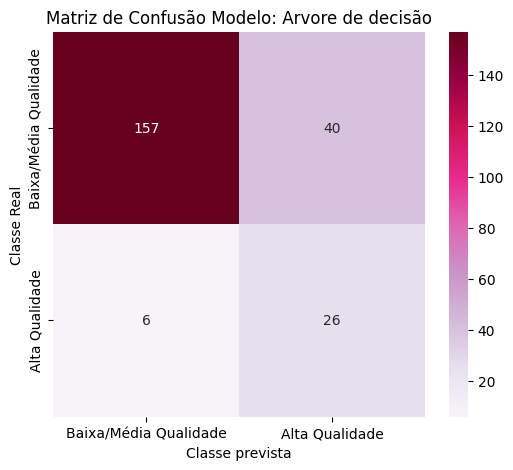

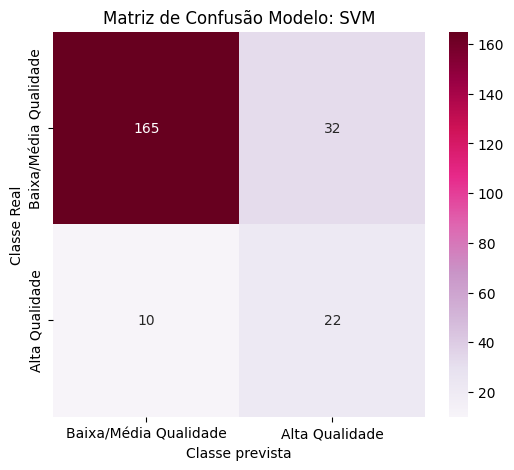

In [ ]:
for nome_modelo,previsao in previsoes.items():
    matriz = confusion_matrix(y_test,previsao)
    plt.figure(figsize=(6,5))
    sns.heatmap(
        matriz,
        annot=True,
        fmt="d",
        cmap="PuRd",
        xticklabels=["Baixa/Média Qualidade","Alta Qualidade"],
        yticklabels=["Baixa/Média Qualidade","Alta Qualidade"]
    )
    plt.title(f"Matriz de Confusão Modelo: {nome_modelo}")
    plt.xlabel("Classe prevista")
    plt.ylabel("Classe Real")
    plt.show()



### 13.4 Comparação dos modelos

Os resultados demonstram que os modelos apresentaram comportamentos distintos na classificação da qualidade dos vinhos.

O SVM obteve a maior acurácia geral, com aproximadamente 81,7%, enquanto a Árvore de Decisão alcançou 79,9%. O SVM também apresentou precisão ligeiramente superior para a classe de alta qualidade, com 40,7%, contra 39,4% da Árvore de Decisão.

Porém, a Árvore de Decisão apresentou uma consideravel melhora do desempenho na identificação dos vinhos realmente classificados como de alta qualidade. Seu recall para a classe 1 foi de 81,3%, enquanto o SVM alcançou 68,8%.

A análise das matrizes de confusão reforça essa diferença. A Árvore de Decisão identificou corretamente 26 dos 32 vinhos de alta qualidade presentes no conjunto de teste, deixando de identificar apenas 6 registros. O SVM identificou corretamente 22 vinhos de alta qualidade e classificou incorretamente 10 registros dessa classe.

Em contrapartida, a Árvore de Decisão apresentou 40 falsos positivos, enquanto o SVM apresentou 32. Isso significa que a Árvore identificou uma quantidade maior de vinhos de alta qualidade, mas também classificou mais vinhos de baixa ou média qualidade como sendo de alta qualidade.

A Árvore de Decisão também apresentou maior acurácia balanceada, com 80,5%, e maior F1-score para a classe de alta qualidade, com 53,1%. O SVM apresentou acurácia balanceada de 76,3% e F1-score de 51,2%.

Considerando o desbalanceamento original da base e a importância de avaliar adequadamente a classe minoritária, a Árvore de Decisão regularizada foi selecionada como o modelo principal. Apesar de apresentar menor acurácia geral e maior quantidade de falsos positivos, o modelo demonstrou maior capacidade de identificar vinhos realmente classificados como de alta qualidade.

Os resultados também indicam que nenhum dos modelos apresentou elevada precisão para a classe de alta qualidade.


## 14. Interpretação do Modelo

Após a comparação dos modelos, a Árvore de Decisão regularizada foi selecionada
por apresentar maior recall, maior acurácia balanceada e maior F1-score para a
classe de alta qualidade.

Nesta etapa, será analisada a importância atribuída pelo modelo a cada
característica físico-química, com o objetivo de identificar quais variáveis
tiveram maior participação nas decisões de classificação.

In [54]:
# Organiza a importancia das variaveis
importancia_variaveis = pd.DataFrame({"Variável":x_treino_balanceado.columns,"Importância":modelo_arvore.feature_importances_})

# Ordenando as variaveis da mais importante para a menos importante
importancia_variaveis = importancia_variaveis.sort_values(by="Importância", ascending=False).reset_index(drop=True)

importancia_variaveis

,Variável,Importância
0,alcohol,0.411859
1,sulphates,0.144740
2,fixed acidity,0.133717
3,total sulfur dioxide,0.095252
4,pH,0.064432
5,chlorides,0.061363
6,citric acid,0.033576
7,volatile acidity,0.024257
8,density,0.022060
9,residual sugar,0.008744


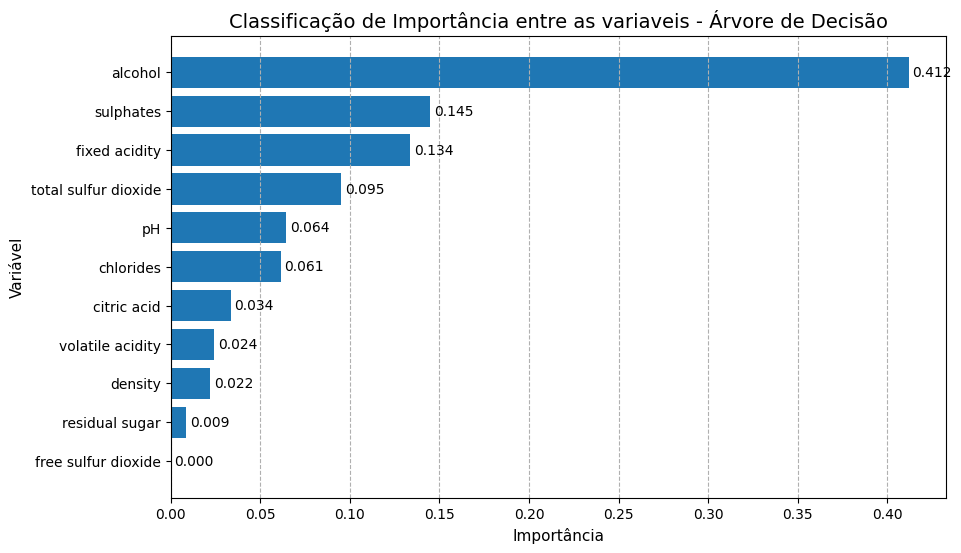

In [ ]:
importancia_variaveis = importancia_variaveis.sort_values(by="Importância",ascending=True)

plt.figure(figsize=(10,6))

barras = plt.barh(importancia_variaveis["Variável"],importancia_variaveis["Importância"])

# Adicionando os valores ao lado das barras
for barra in barras:
    largura = barra.get_width()
    plt.text(
        largura + 0.002,
        barra.get_y() + barra.get_height()/2,
        f"{largura:.3f}",
        va="center"
    )

# Titulos e Rótulos
plt.title("Classificação de Importância entre as variaveis - Árvore de Decisão", fontsize=14)
plt.xlabel("Importância",fontsize=11)
plt.ylabel("Variável", fontsize=11)

# Adicionando grade ao grafico
plt.grid(axis="x",linestyle="--")

# Plotando o gráfico
plt.show()

In [92]:
# Criação de coluna em percentual de importancia
importancia_variaveis["Importância (%)"] = (importancia_variaveis["Importância"] * 100).round(2)

# Organizando do maior ao menor
importancia_variaveis = importancia_variaveis.sort_values(by="Importância (%)",ascending=False)

importancia_variaveis

,Variável,Importância,Importância (%)
0,alcohol,0.411859,41.19
1,sulphates,0.144740,14.47
2,fixed acidity,0.133717,13.37
3,total sulfur dioxide,0.095252,9.53
4,pH,0.064432,6.44
5,chlorides,0.061363,6.14
6,citric acid,0.033576,3.36
7,volatile acidity,0.024257,2.43
8,density,0.022060,2.21
9,residual sugar,0.008744,0.87


### 14.1 Interpretação da importância das variáveis

A análise da Árvore de Decisão demonstra que o teor alcoólico foi a variável mais relevante para a classificação dos vinhos, concentrando aproximadamente **41,19% da importância atribuída pelo modelo**.

Esse resultado condiz com a matriz de correlação apresentada anteriormente, na qual foi possivel observar que o teor alcoólico também apresentou a maior correlação positiva com a classificação de alta qualidade. Dessa forma, valores de teor alcoólico foram particularmente úteis para a Árvore de Decisão distinguir vinhos de baixa/média qualidade dos vinhos de alta qualidade.

A variável `sulphates` apresentou a segunda maior importância, com aproximadamente **14,47%**, seguida por `fixed acidity`, com **13,37%**, e `total sulfur dioxide`, com **9,53%**.

Em conjunto, essas quatro variáveis representam aproximadamente **78,56% da importância total do modelo**, demonstrando que grande parte das decisões da árvore foi baseada nessas características.

As variáveis `pH` e `chlorides` também apresentaram participação relevante, com **6,44%** e **6,14%**, respectivamente. As demais características contribuíram em menor escala para as decisões do modelo.

A variável `free sulfur dioxide` recebeu importância igual a zero. Isso significa que ela não foi utilizada nas divisões realizadas pela árvore treinada. Esse resultado é um indicativo, mas não uma conclusão, de que a variável é irrelevante para a classificação dos vinhos, pois podem existir contextos em que apenas que ela seja importante, dado que modelos diferentes terão regras diferentes.

É importante destacar que a importância das variáveis indica o quanto cada característica foi utilizada pelo modelo para separar as classes, mas não informa diretamente se o aumento de uma variável eleva ou reduz a probabilidade de alta qualidade.

Para interpretar a direção dessas relações, foram considerados também os resultados da análise de correlação. Nessa análise, `alcohol`, `sulphates` e `fixed acidity` apresentaram associações positivas com a classe de alta qualidade, enquanto `total sulfur dioxide` apresentou uma associação negativa de menor intensidade.

### 14.2 Relação dos resultados com o contexto enológico

O resultado obtido em relação a importancia do teor alcoolico para a classificação dos vinhos de alta qualidade encontra respaldo em conteúdos especializados do setor vitivinícola. O álcool exerce influência sobre diferentes características sensoriais do vinho, como corpo, textura, sensação de calor e intensidade aromática. Em geral, vinhos com maior graduação alcoólica tendem a apresentar maior volume e presença no paladar.

Entretanto, o teor alcoólico elevado não deve ser interpretado isoladamente como indicativo de alta qualidade. A contribuição do álcool depende de sua integração com outros componentes, como acidez, taninos, concentração de fruta e compostos aromáticos. Quando o álcool se destaca de forma excessiva, o vinho pode apresentar sensação de calor, peso e desequilíbrio.

Dessa forma, o resultado do modelo não significa que o aumento do teor alcoólico produzirá necessariamente um vinho melhor. Essa interpretação também é coerente com as demais variáveis consideradas importantes pelo modelo, como `sulphates`, `fixed acidity`, `total sulfur dioxide`, `pH` e `chlorides`. A qualidade percebida parece resultar da interação entre diferentes características físico-químicas, e não da atuação isolada de um único componente.

No processo produtivo, essas informações podem auxiliar no acompanhamento da maturação das uvas, da concentração de açúcares, da fermentação e do equilíbrio entre álcool e acidez. Entretanto, qualquer ajuste deve considerar o estilo de vinho pretendido, pois vinhos leves, frescos e encorpados apresentam graduações alcoólicas distintas e ainda assim podem alcançar qualidade elevada.

#### Referências consultadas

* [Evino — Teor alcoólico no vinho: como ele define corpo, equilíbrio e sabor](https://www.evino.com.br/blog/teor-alcoolico-vinho-abv/)
* [Famiglia Valduga — Como a graduação alcoólica interfere no sabor de um vinho?](https://blog.famigliavalduga.com.br/como-a-graduacao-alcoolica-interfere-no-sabor-de-um-vinho/)
* [Cortez et al. — Modeling wine preferences by data mining from physicochemical properties](https://doi.org/10.1016/j.dss.2009.05.016)


## 15. Conclusão

Este projeto teve como objetivo desenvolver modelos de Machine Learning capazes de classificar vinhos como de baixa/média qualidade ou de alta qualidade, utilizando suas características físico-químicas.

Inicialmente, foi realizada uma análise exploratória dos dados, incluindo a verificação de valores ausentes, distribuição das variáveis, identificação de possíveis outliers, análise do balanceamento das classes e avaliação das correlações entre as características.

A variável-alvo apresentou desbalanceamento, com aproximadamente **86,09%** dos registros pertencentes à classe de baixa/média qualidade e **13,91%** à classe de alta qualidade. Para reduzir o impacto desse cenário no treinamento, foi aplicado oversampling aleatório exclusivamente sobre o conjunto de treino, mantendo o conjunto de teste com sua distribuição original.

Foram desenvolvidos e comparados dois modelos de classificação: **Árvore de Decisão** e **Support Vector Machine (SVM)**.

O SVM apresentou a maior acurácia geral, com aproximadamente **81,66%**, enquanto a Árvore de Decisão alcançou **79,91%**. Entretanto, devido ao desbalanceamento original das classes, outras métricas também foram consideradas na comparação.

A Árvore de Decisão apresentou recall de **81,25%** para a classe de alta qualidade, identificando corretamente 26 dos 32 vinhos dessa classe presentes no conjunto de teste. O SVM apresentou recall de **68,75%**, identificando corretamente 22 registros.

A Árvore de Decisão também apresentou maior acurácia balanceada, com aproximadamente **80,47%**, e maior F1-score para a classe de alta qualidade, com **53,06%**. Por outro lado, o SVM apresentou precisão ligeiramente superior para essa classe e produziu uma quantidade menor de falsos positivos.

Considerando a maior capacidade de identificar vinhos realmente classificados como de alta qualidade, a Árvore de Decisão regularizada foi selecionada como o modelo principal. Entretanto, sua precisão de aproximadamente **39,39%** demonstra que uma parcela relevante dos vinhos previstos como de alta qualidade pertencia, na realidade, à classe de baixa/média qualidade.

A análise da importância das variáveis demonstrou que o teor alcoólico (`alcohol`) foi a característica mais relevante para as decisões da Árvore de Decisão, concentrando aproximadamente **41,19%** da importância total. Em seguida, destacaram-se `sulphates`, `fixed acidity` e `total sulfur dioxide`.

Os resultados indicam que as características físico-químicas podem auxiliar na identificação da qualidade dos vinhos. 

### Limitações

Entre as principais limitações do projeto está a baixa quantidade de vinhos de alta qualidade no conjunto de dados. No conjunto de teste, essa classe foi representada por apenas 32 registros, fazendo com que pequenas variações nas previsões provoquem alterações relevantes nas métricas. Além disso, o oversampling aleatório utilizado duplica registros da classe minoritária, o que pode aumentar o risco de overfitting.